In [15]:
# Nettoyage complet
print("Nettoyage...")
%reset -f

%whos

Nettoyage...
Interactive namespace is empty.


In [16]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
import pickle

In [17]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

In [18]:
# Les requêtes : 

requete_lots_infos_basiques = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    l.lot_date_creation,
    l.lot_date_archive,
    l.lot_surface,
    l.lot_batiment,
    l.etage_id,
    l.adresse_id,
    o.negociateur_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_offre o ON o.offre_id = tj.offre_id ;
"""

requete_lots_adresses = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    a.adresse_id,
    a.adr_adresse,
    a.adr_adresse_cp,
    a.adr_adresse_ville,
    CAST(a.adr_plan_x AS FLOAT) AS adr_plan_x,
    CAST(a.adr_plan_y AS FLOAT) AS adr_plan_y,
    CAST(a.adr_geo_location AS VARCHAR(255)) AS adr_geo_location,
    a.code_insee_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
"""

requete_gestion_de_lots_negociateurs = """
-- Requête comptage du nombre de lots qui ont été un jour en contact avec chaque négociateur
-- Pour trouver la distribution de l'"efficacité" des négociateurs

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    COUNT(DISTINCT tj.lot_id) AS nombre_lots_associes
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_offre o
    ON o.negociateur_id = n.negociateur_id
LEFT JOIN dbo.tj_offre_lot tj
    ON tj.offre_id = o.offre_id
GROUP BY
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif
HAVING COUNT(DISTINCT tj.lot_id) != 0
"""

requete_transactions_revenus_negociateurs =""" 
-- Maintenant, requête qui va chercher le nombre de transactions qu'ont fait chaque négociateur, 
-- et les revenus que ça a rapporté. Le but est de trouver leur spécialisation sur la base des recettes 
-- par transaction, mais aussi de comparer la quantité de lots avec lesquels ils ont été en contact
-- avec la quantité de transactions dans lesquelles ils vont être impliqués par la suite

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    n.groupe_id,
    n.agence_id,
    COUNT(t.transaction_id) AS nombre_transactions,
    SUM(t.tra_loyer) AS montant_total_transactions
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_transaction t
    ON t.negociateur_id = n.negociateur_id
GROUP BY
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    n.groupe_id,
    n.agence_id
HAVING COUNT(t.transaction_id) > 0
"""

# Ici on a remonté toutes les données qui ont un jour été actives dans LogiPro, pas seulement celles qui
# sont actives aujourd'hui.
# On a gardé dans toutes les requêtes la colonne actif ou non pour pouvoir filtrer après.

In [19]:
lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)
print(lots_infos_basiques.columns)

lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)
print(lots_adresses.columns)

gestion_de_lots_negociateurs = pd.read_sql_query(requete_gestion_de_lots_negociateurs, conn)
print(gestion_de_lots_negociateurs.columns)

transactions_revenus_negociateurs = pd.read_sql_query(requete_transactions_revenus_negociateurs, conn)
print(transactions_revenus_negociateurs.columns)

C:\Users\quent\AppData\Local\Temp\ipykernel_16616\944866181.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)


Index(['lot_id', 'lot_actif', 'lot_date_creation', 'lot_date_archive',
       'lot_surface', 'lot_batiment', 'etage_id', 'adresse_id',
       'negociateur_id'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_16616\944866181.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)


Index(['lot_id', 'lot_actif', 'adresse_id', 'adr_adresse', 'adr_adresse_cp',
       'adr_adresse_ville', 'adr_plan_x', 'adr_plan_y', 'adr_geo_location',
       'code_insee_id'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_16616\944866181.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gestion_de_lots_negociateurs = pd.read_sql_query(requete_gestion_de_lots_negociateurs, conn)


Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif',
       'nombre_lots_associes'],
      dtype='object')
Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif', 'groupe_id',
       'agence_id', 'nombre_transactions', 'montant_total_transactions'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_16616\944866181.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions_revenus_negociateurs = pd.read_sql_query(requete_transactions_revenus_negociateurs, conn)


In [20]:
conn.commit()
cursor.close()
conn.close()

In [21]:
# Filtrer sur la France métropolitaine (en degrés WGS84)
lots_adresses = lots_adresses[
    (lots_adresses['adr_plan_x'] >= -5.0) & (lots_adresses['adr_plan_x'] <= 10.0) &  # longitudes
    (lots_adresses['adr_plan_y'] >= 41.0) & (lots_adresses['adr_plan_y'] <= 52.0)    # latitudes
].copy()

print(f"✅ Nombre de lots après filtrage : {len(lots_adresses):,}")

✅ Nombre de lots après filtrage : 2,297,693


<Axes: >

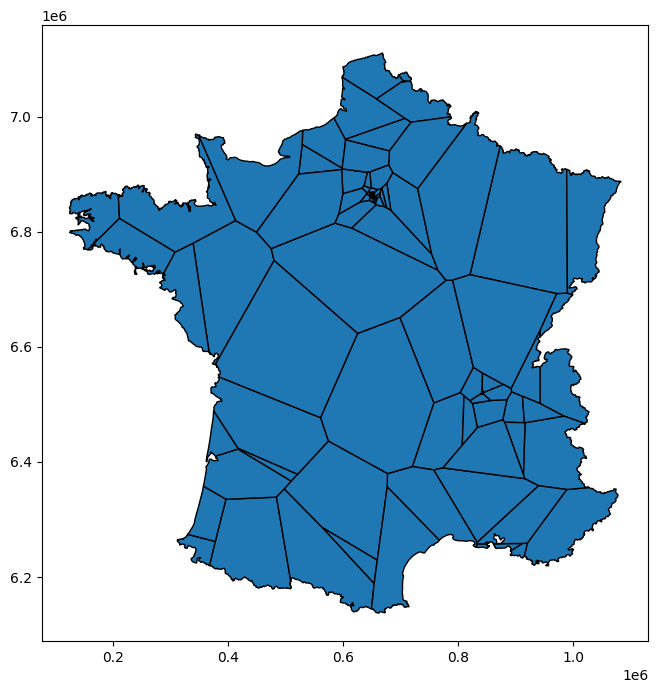

In [22]:
# Deuxième chose : on charge les régions de Voronoi des agences

gdf_agences_polygones = gpd.read_file("gdf_agences_polygones.geojson")
gdf_agences_polygones.plot(edgecolor="black", figsize=(8, 8))

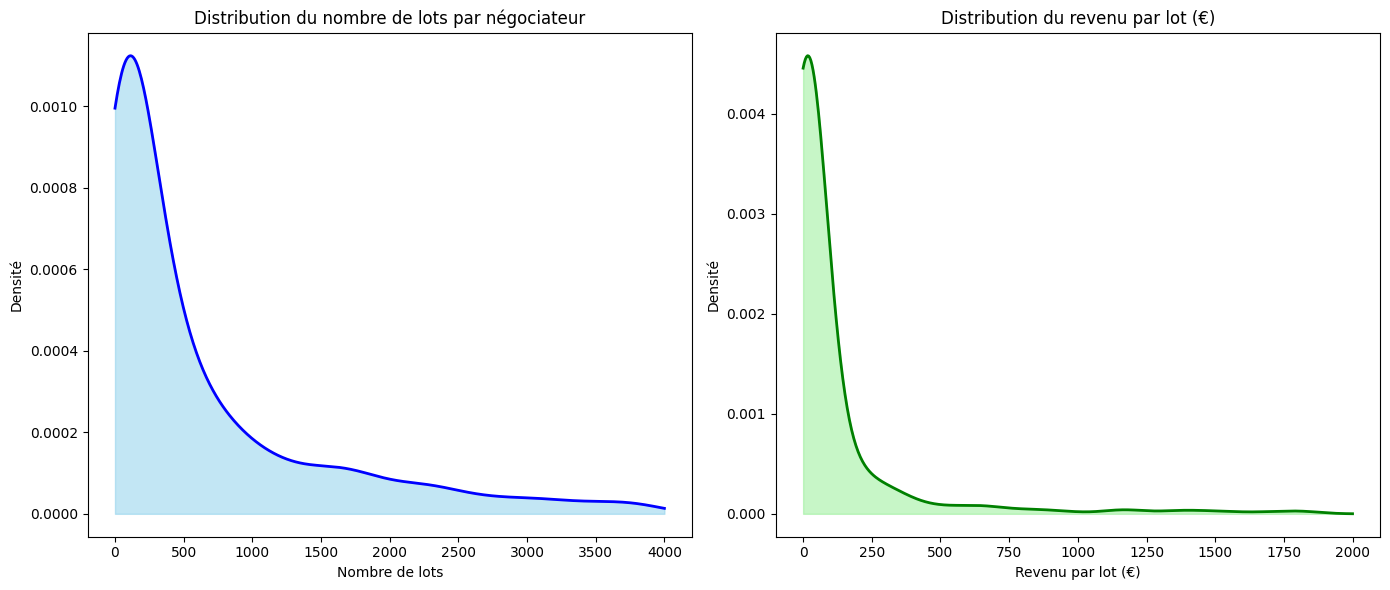

In [23]:
# On ouvre maintenant les distributions du nombre de lots gérés par négociateur et du revenu moyen par
# transaction par négociateur : 

with open("kde_nb_lots_negos.pkl", "rb") as f:
    kde_nb_lots_negos = pickle.load(f)

with open("kde_revenus_par_lot.pkl", "rb") as f:
    kde_revenus_par_lot = pickle.load(f)

# Définir les plages de valeurs pour chaque distribution
x_lots = np.linspace(0, 4000, 500)      # pour le nombre de lots par négociateur
x_revenus = np.linspace(0, 2000, 500)   # pour le revenu par lot (€)

# Évaluer les densités
y_lots = kde_nb_lots_negos.evaluate(x_lots)
y_revenus = kde_revenus_par_lot.evaluate(x_revenus)

# Créer les graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Distribution du nombre de lots par négociateur
axes[0].plot(x_lots, y_lots, color='blue', lw=2)
axes[0].fill_between(x_lots, y_lots, color='skyblue', alpha=0.5)
axes[0].set_title("Distribution du nombre de lots par négociateur")
axes[0].set_xlabel("Nombre de lots")
axes[0].set_ylabel("Densité")

# 2. Distribution du revenu par lot
axes[1].plot(x_revenus, y_revenus, color='green', lw=2)
axes[1].fill_between(x_revenus, y_revenus, color='lightgreen', alpha=0.5)
axes[1].set_title("Distribution du revenu par lot (€)")
axes[1].set_xlabel("Revenu par lot (€)")
axes[1].set_ylabel("Densité")

plt.tight_layout()
plt.show()

✅ CRS des lots : EPSG:2154
✅ CRS des agences : EPSG:2154


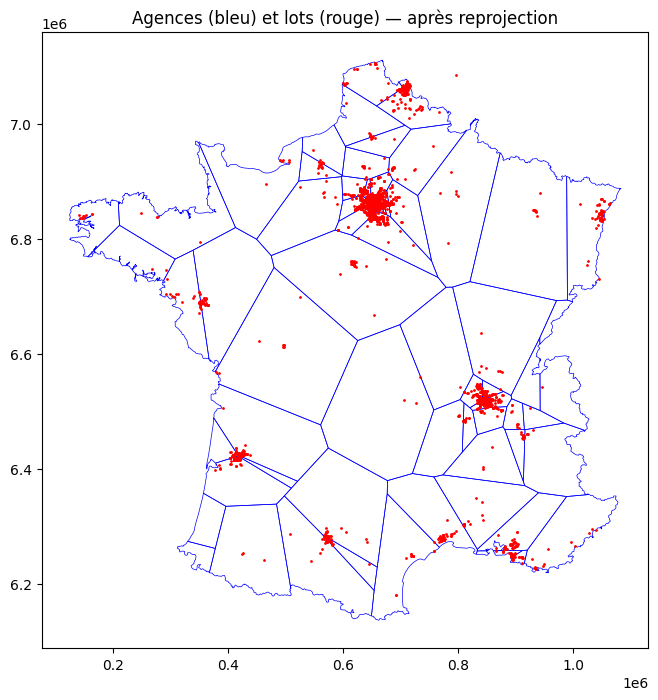

✅ 2,295,962 lots sur 2,297,693 ont été associés à une agence (99.92%).
     lot_id  agence_id
90     -370      370.0
312   10045      171.0
313   10167       76.0
334   10823      345.0
335   10824      345.0


In [24]:
# On formate ici le dataframe lots_agences pour pouvoir ensuite relier chaque lot à une agence

# Les coordonnées actuelles sont en degrés (WGS84)
gdf_lots = gpd.GeoDataFrame(
    lots_adresses.copy(),
    geometry=gpd.points_from_xy(lots_adresses["adr_plan_x"], lots_adresses["adr_plan_y"]),
    crs="EPSG:4326"  # système géographique
)

gdf_lots = gdf_lots.to_crs(epsg=2154)

print("✅ CRS des lots :", gdf_lots.crs)
print("✅ CRS des agences :", gdf_agences_polygones.crs)

fig, ax = plt.subplots(figsize=(8, 8))
gdf_agences_polygones.plot(ax=ax, color='none', edgecolor='blue', linewidth=0.5)
gdf_lots.sample(5000).plot(ax=ax, color='red', markersize=1)
plt.title("Agences (bleu) et lots (rouge) — après reprojection")
plt.show()

gdf_lots_agences = gpd.sjoin(
    gdf_lots,
    gdf_agences_polygones[['agence_id', 'geometry']],
    how="left",
    predicate="within"
)

nb_associes = gdf_lots_agences['agence_id'].notna().sum()
total_lots = len(gdf_lots_agences)
print(f"✅ {nb_associes:,} lots sur {total_lots:,} ont été associés à une agence ({nb_associes/total_lots:.2%}).")

lots_agences = gdf_lots_agences[['lot_id', 'agence_id']].copy()
print(lots_agences.head())

✅ 2,295,962 lots sur 2,297,693 ont été associés à une agence (99.92%).
Tableau provisoire (reste à ajouter le négociateur) :
     lot_id  agence_id
90     -370      370.0
312   10045      171.0
313   10167       76.0
334   10823      345.0
335   10824      345.0


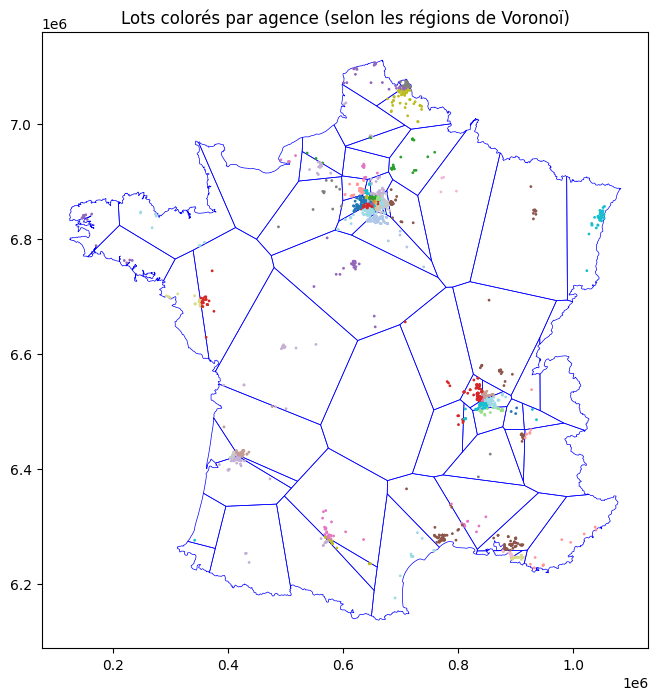

In [25]:
# On associe maintenant chaque lot à la région de Voronoï de son agence

gdf_lots_agences = gpd.sjoin(
    gdf_lots,
    gdf_agences_polygones[['agence_id', 'geometry']],
    how="left",
    predicate="within"
)

nb_associes = gdf_lots_agences['agence_id'].notna().sum()
total_lots = len(gdf_lots_agences)
print(f"✅ {nb_associes:,} lots sur {total_lots:,} ont été associés à une agence ({nb_associes/total_lots:.2%}).")

lots_agences = gdf_lots_agences[['lot_id', 'agence_id']].copy()

print("Tableau provisoire (reste à ajouter le négociateur) :")
print(lots_agences.head())

# On voit ce que ca donne visuellement
fig, ax = plt.subplots(figsize=(8, 8))
gdf_agences_polygones.plot(ax=ax, color='none', edgecolor='blue', linewidth=0.5)
gdf_lots_agences.sample(5000).plot(ax=ax, column='agence_id', markersize=1, cmap='tab20', legend=False)
plt.title("Lots colorés par agence (selon les régions de Voronoï)")
plt.show()

In [26]:
# === Fusion de lots_adresses (avec agence_id) et lots_infos_basiques (avec negociateur_id)
lots_agences = lots_agences.merge(
    lots_infos_basiques[['lot_id', 'negociateur_id']],
    on='lot_id',
    how='left'
)

# === Vérification rapide
print("✅ Fusion terminée !")
print("Nombre de lignes :", len(lots_agences))
print("Nombre de lots avec un négociateur associé :", lots_agences['negociateur_id'].notna().sum())
print(lots_agences.head())

✅ Fusion terminée !
Nombre de lignes : 3754009
Nombre de lots avec un négociateur associé : 3754009
   lot_id  agence_id  negociateur_id
0    -370      370.0               0
1   10045      171.0              91
2   10167       76.0              88
3   10823      345.0              86
4   10824      345.0              86


In [27]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

requete_nb_lots_negos = """ 
SELECT 
    o.negociateur_id,
    COUNT(*) AS negociateur_nb_lots_geres
FROM dbo.tj_offre_lot tj
JOIN dbo.t_offre o 
    ON tj.offre_id = o.offre_id
WHERE tj.ol_actif = 1   -- on ne compte que les lots actifs
GROUP BY o.negociateur_id
ORDER BY negociateur_nb_lots_geres DESC;
"""

nb_lots_negos = pd.read_sql_query(requete_nb_lots_negos, conn)

conn.commit()
cursor.close()
conn.close()

C:\Users\quent\AppData\Local\Temp\ipykernel_16616\3936372491.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  nb_lots_negos = pd.read_sql_query(requete_nb_lots_negos, conn)


In [28]:
# On ajoute une colonne qui contient le nombre de lots que gère en ce moment le négociateur

negociateur_counts = (
    lots_agences.groupby("negociateur_id", as_index=False)
    .size()
    .rename(columns={"size": "negociateur_type"})
)

lots_agences = lots_agences.merge(
    negociateur_counts,
    on="negociateur_id",
    how="left"
)

print("Nombre de lignes :", len(lots_agences))
print(lots_agences.head())

Nombre de lignes : 3754009
   lot_id  agence_id  negociateur_id  negociateur_type
0    -370      370.0               0              5361
1   10045      171.0              91              4741
2   10167       76.0              88               718
3   10823      345.0              86              3577
4   10824      345.0              86              3577


In [30]:
lots_agences.to_csv("lots_agences_negos.csv", index=False)